# ECG Analysis - Record 100: Normal Sinus Rhythm
This notebook performs 5 different signal processing techniques on this specific ECG record.

In [1]:
import wfdb
import numpy as np
from scipy import signal
import pywt
import matplotlib.pyplot as plt

# Load records
def load_ecg_case(record_name):
    record = wfdb.rdrecord(record_name, pn_dir='mitdb')
    ecg_signal = record.p_signal[:10000, 0]  # First 10000 samples (~27 seconds)
    fs = record.fs  # 360 Hz
    return ecg_signal, fs

# Simple preprocessing
def preprocess_ecg(ecg, fs):
    # High-pass filter (remove baseline)
    sos = signal.butter(4, 0.5, btype='high', fs=fs, output='sos')
    ecg_clean = signal.sosfiltfilt(sos, ecg)
    
    # Notch filter (remove 60Hz)
    b, a = signal.iirnotch(60, 30, fs)
    ecg_clean = signal.filtfilt(b, a, ecg_clean)
    
    return ecg_clean

# Detect R-peaks (simple threshold method)
def detect_r_peaks(ecg, fs):
    # Simple derivative + squaring
    diff_ecg = np.diff(ecg)
    squared = diff_ecg ** 2
    
    # Moving average
    window = int(0.15 * fs)
    integrated = np.convolve(squared, np.ones(window)/window, mode='same')
    
    # Find peaks
    from scipy.signal import find_peaks
    peaks, _ = find_peaks(integrated, distance=int(0.2*fs), height=np.mean(integrated))
    
    return peaks

def histogram_analysis(ecg, fs):
    """
    Analyze RR interval distribution
    Returns: histogram data + diagnostic parameters
    """
    # Detect R-peaks
    r_peaks = detect_r_peaks(ecg, fs)
    
    # Calculate RR intervals (in milliseconds)
    rr_intervals = np.diff(r_peaks) / fs * 1000
    
    # Diagnostic Parameters
    params = {
        'mean_rr': np.mean(rr_intervals),
        'std_rr': np.std(rr_intervals),
        'cv_rr': np.std(rr_intervals) / np.mean(rr_intervals),  # Coefficient of variation
        'min_rr': np.min(rr_intervals),
        'max_rr': np.max(rr_intervals),
        'range_rr': np.max(rr_intervals) - np.min(rr_intervals),
        'mean_hr': 60000 / np.mean(rr_intervals),  # Heart rate in bpm
    }
    
    # DIAGNOSTIC RULES
    diagnosis = []
    if params['std_rr'] > 100:
        diagnosis.append("HIGH IRREGULARITY (std > 100ms)")
    if params['cv_rr'] > 0.15:
        diagnosis.append("HIGH VARIABILITY (CV > 0.15)")
    if params['range_rr'] > 400:
        diagnosis.append("WIDE RR RANGE (>400ms)")
    
    if not diagnosis:
        diagnosis.append("NORMAL RHYTHM")
    
    return rr_intervals, params, diagnosis

def wavelet_analysis(ecg, fs):
    """
    Wavelet decomposition and energy analysis
    """
    # Perform DWT (5 levels)
    coeffs = pywt.wavedec(ecg, 'db4', level=5)
    
    # Calculate energy in each level
    energies = [np.sum(c**2) for c in coeffs]
    total_energy = sum(energies)
    energy_percentages = [e/total_energy * 100 for e in energies]
    
    # Diagnostic Parameters
    params = {
        'energy_distribution': energy_percentages,
        'detail_energy': sum(energy_percentages[1:]),  # All detail coefficients
        'approx_energy': energy_percentages[0],  # Approximation
        'dominant_level': np.argmax(energy_percentages),
    }
    
    # DIAGNOSTIC RULES
    diagnosis = []
    
    # Normal ECG: Most energy in approximation (low freq) + D1-D2 (QRS)
    # Arrhythmia: Energy spread across multiple detail levels
    if params['detail_energy'] > 60:
        diagnosis.append("ABNORMAL ENERGY DISTRIBUTION (Details > 60%)")
    
    if params['dominant_level'] > 2:
        diagnosis.append("DOMINANT ENERGY IN HIGH DETAILS (Noisy/Abnormal)")
    
    if not diagnosis:
        diagnosis.append("NORMAL WAVELET PATTERN")
    
    return coeffs, params, diagnosis

def stft_analysis(ecg, fs):
    """
    Short-Time Fourier Transform
    """
    # Compute STFT
    f, t, Zxx = signal.stft(ecg, fs, nperseg=256, noverlap=250)
    
    # Power spectrogram
    spectrogram = np.abs(Zxx) ** 2
    
    # Diagnostic Parameters
    # Focus on 0-10 Hz (cardiac relevant frequencies)
    freq_mask = f <= 10
    f_cardiac = f[freq_mask]
    spec_cardiac = spectrogram[freq_mask, :]
    
    # Temporal stability of dominant frequency
    dominant_freqs = f_cardiac[np.argmax(spec_cardiac, axis=0)]
    
    params = {
        'mean_dominant_freq': np.mean(dominant_freqs),
        'std_dominant_freq': np.std(dominant_freqs),
        'freq_stability_cv': np.std(dominant_freqs) / np.mean(dominant_freqs) if np.mean(dominant_freqs) > 0 else 0,
        'freq_range': np.max(dominant_freqs) - np.min(dominant_freqs),
    }
    
    # DIAGNOSTIC RULES
    diagnosis = []
    
    if params['std_dominant_freq'] > 0.3:
        diagnosis.append("UNSTABLE FREQUENCY CONTENT (std > 0.3 Hz)")
    
    if params['freq_stability_cv'] > 0.2:
        diagnosis.append("HIGH FREQUENCY VARIABILITY (CV > 0.2)")
    
    if params['freq_range'] > 1.5:
        diagnosis.append("WIDE FREQUENCY RANGE (>1.5 Hz)")
    
    if not diagnosis:
        diagnosis.append("STABLE FREQUENCY PATTERN")
    
    return f, t, Zxx, params, diagnosis

def fft_analysis(ecg, fs):
    """
    Standard FFT analysis
    """
    # Compute FFT
    N = len(ecg)
    fft_vals = np.fft.fft(ecg)
    fft_freq = np.fft.fftfreq(N, 1/fs)
    
    # Get positive frequencies only
    pos_mask = fft_freq > 0
    freqs = fft_freq[pos_mask]
    power = np.abs(fft_vals[pos_mask]) ** 2
    
    # Focus on cardiac frequencies (0.5 - 5 Hz)
    cardiac_mask = (freqs >= 0.5) & (freqs <= 5)
    cardiac_freqs = freqs[cardiac_mask]
    cardiac_power = power[cardiac_mask]
    
    # Find peaks
    from scipy.signal import find_peaks
    peaks_idx, properties = find_peaks(cardiac_power, height=np.max(cardiac_power)*0.1)
    peak_freqs = cardiac_freqs[peaks_idx]
    
    # Diagnostic Parameters
    params = {
        'num_peaks': len(peak_freqs),
        'dominant_freq': cardiac_freqs[np.argmax(cardiac_power)],
        'dominant_hr': cardiac_freqs[np.argmax(cardiac_power)] * 60,  # Convert to bpm
        'peak_frequencies': peak_freqs,
        'spectral_energy': np.sum(cardiac_power),
    }
    
    # DIAGNOSTIC RULES
    diagnosis = []
    
    # Normal: 1-2 clear peaks around 1-1.5 Hz (60-90 bpm)
    # Arrhythmia: Multiple peaks, or peaks outside normal range
    
    if params['num_peaks'] > 3:
        diagnosis.append("MULTIPLE FREQUENCY PEAKS (>3)")
    
    if params['dominant_hr'] < 50 or params['dominant_hr'] > 120:
        diagnosis.append(f"ABNORMAL HEART RATE ({params['dominant_hr']:.1f} bpm)")
    
    if params['num_peaks'] == 0:
        diagnosis.append("NO CLEAR DOMINANT FREQUENCY")
    
    if not diagnosis:
        diagnosis.append("NORMAL FREQUENCY SPECTRUM")
    
    return freqs, power, params, diagnosis

def entropy_analysis(ecg, fs):
    """
    Calculate different entropy measures (OPTIMIZED)
    """
    # Use a subset of data for faster computation
    ecg_subset = ecg[:5000]  # Use first 5000 samples instead of all
    
    # 1. Shannon Entropy (overall complexity)
    hist, _ = np.histogram(ecg_subset, bins=50, density=True)
    hist = hist[hist > 0]  # Remove zeros
    shannon_entropy = -np.sum(hist * np.log2(hist))
    
    # 2. Approximate Entropy (SIMPLIFIED VERSION)
    def approximate_entropy_fast(signal, m=2, r=None):
        """Faster ApEn implementation"""
        if r is None:
            r = 0.2 * np.std(signal)
        
        N = len(signal)
        
        def _phi(m):
            patterns = []
            for i in range(N - m + 1):
                patterns.append(signal[i:i+m])
            patterns = np.array(patterns)
            
            C = []
            for i in range(len(patterns)):
                # Count patterns within tolerance r
                dists = np.max(np.abs(patterns - patterns[i]), axis=1)
                count = np.sum(dists <= r)
                C.append(count / (N - m + 1.0))
            
            return np.mean(np.log(C))
        
        return abs(_phi(m + 1) - _phi(m))
    
    # 3. Sample Entropy (SIMPLIFIED VERSION)
    def sample_entropy_fast(signal, m=2, r=None):
        """Faster SampEn implementation"""
        if r is None:
            r = 0.2 * np.std(signal)
        
        N = len(signal)
        
        def _phi(m):
            patterns = []
            for i in range(N - m):
                patterns.append(signal[i:i+m])
            patterns = np.array(patterns)
            
            B = 0
            for i in range(len(patterns)):
                dists = np.max(np.abs(patterns - patterns[i]), axis=1)
                B += np.sum((dists <= r) & (np.arange(len(patterns)) != i))
            
            return B
        
        A = _phi(m + 1)
        B = _phi(m)
        
        return -np.log(A / B) if B != 0 and A != 0 else 0
    
    try:
        print("   Computing Approximate Entropy...")
        apen = approximate_entropy_fast(ecg_subset)
        print("   Computing Sample Entropy...")
        sampen = sample_entropy_fast(ecg_subset)
    except Exception as e:
        print(f"   Warning: Entropy calculation error: {e}")
        apen = 0
        sampen = 0
    
    # Diagnostic Parameters
    params = {
        'shannon_entropy': shannon_entropy,
        'approximate_entropy': apen,
        'sample_entropy': sampen,
    }
    
    # DIAGNOSTIC RULES
    diagnosis = []
    
    # Normal ECG: ApEn around 0.8-1.2, SampEn around 0.5-1.0
    # Arrhythmia: Higher entropy (more irregular/chaotic)
    
    if apen > 1.5:
        diagnosis.append("HIGH APPROXIMATE ENTROPY (>1.5) - IRREGULAR")
    elif apen < 0.5 and apen > 0:
        diagnosis.append("VERY LOW ENTROPY (<0.5) - OVERLY REGULAR")
    
    if sampen > 1.2:
        diagnosis.append("HIGH SAMPLE ENTROPY (>1.2) - CHAOTIC")
    
    if not diagnosis:
        diagnosis.append("NORMAL ENTROPY RANGE")
    
    return params, diagnosis



ANALYZING: Normal Sinus Rhythm (Record 100)


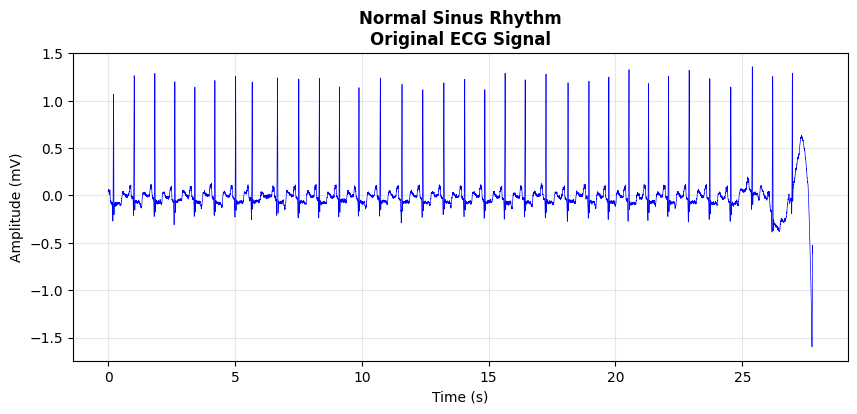

In [2]:
record_name = '100'
case_label = 'Normal Sinus Rhythm'

print(f"ANALYZING: {case_label} (Record {record_name})")
# Load and preprocess
ecg, fs = load_ecg_case(record_name)
ecg_clean = preprocess_ecg(ecg, fs)

# Original Signal
plt.figure(figsize=(10, 4))
time = np.arange(len(ecg_clean)) / fs
plt.plot(time, ecg_clean, 'b', linewidth=0.5)
plt.title(f'{case_label}\nOriginal ECG Signal', fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.grid(True, alpha=0.3)
plt.show()


### 1. Histogram Analysis
Analyzing the RR interval distribution to detect irregular heartbeats.

1. HISTOGRAM ANALYSIS


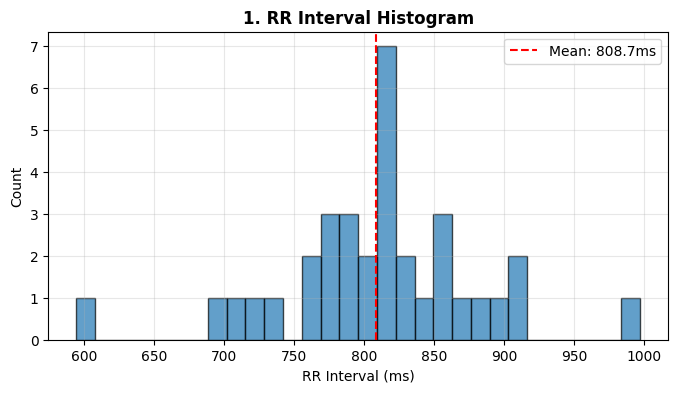

   Mean RR: 808.74 ms
   Std RR: 71.80 ms
   CV: 0.089
   Diagnosis: WIDE RR RANGE (>400ms)


In [4]:
print("1. HISTOGRAM ANALYSIS")
rr_intervals, hist_params, hist_diag = histogram_analysis(ecg_clean, fs)

plt.figure(figsize=(8, 4))
plt.hist(rr_intervals, bins=30, edgecolor='black', alpha=0.7)
plt.title('1. RR Interval Histogram', fontweight='bold')
plt.xlabel('RR Interval (ms)')
plt.ylabel('Count')
plt.axvline(hist_params['mean_rr'], color='r', linestyle='--', label=f"Mean: {hist_params['mean_rr']:.1f}ms")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"   Mean RR: {hist_params['mean_rr']:.2f} ms")
print(f"   Std RR: {hist_params['std_rr']:.2f} ms")
print(f"   CV: {hist_params['cv_rr']:.3f}")
print(f"   Diagnosis: {', '.join(hist_diag)}")


### 2. Wavelet Analysis
Discrete Wavelet Transform (DWT) decomposition to analyze energy distribution across frequency bands.

In [ ]:
print("2. WAVELET ANALYSIS")
coeffs, wav_params, wav_diag = wavelet_analysis(ecg_clean, fs)

plt.figure(figsize=(8, 4))
levels = ['A5', 'D5', 'D4', 'D3', 'D2', 'D1']
plt.bar(levels, wav_params['energy_distribution'])
plt.title('2. Wavelet Energy Distribution', fontweight='bold')
plt.xlabel('Decomposition Level')
plt.ylabel('Energy (%)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"   Energy Distribution: {[f'{e:.1f}%' for e in wav_params['energy_distribution']]}")
print(f"   Detail Energy: {wav_params['detail_energy']:.1f}%")
print(f"   Diagnosis: {', '.join(wav_diag)}
")


### 3. Short-Time Fourier Transform (STFT)
Time-frequency analysis to observe how frequency content changes over time (spectrogram).

In [ ]:
print("3. STFT ANALYSIS")
f_stft, t_stft, Zxx, stft_params, stft_diag = stft_analysis(ecg_clean, fs)

plt.figure(figsize=(10, 4))
freq_mask = f_stft <= 10
im = plt.pcolormesh(t_stft, f_stft[freq_mask], 10*np.log10(np.abs(Zxx[freq_mask, :])**2), 
                    shading='gouraud', cmap='jet')
plt.title('3. STFT Spectrogram (0-10 Hz)', fontweight='bold')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.colorbar(im, label='Power (dB)')
plt.show()

print(f"   Mean Dominant Freq: {stft_params['mean_dominant_freq']:.3f} Hz")
print(f"   Freq Stability (CV): {stft_params['freq_stability_cv']:.3f}")
print(f"   Diagnosis: {', '.join(stft_diag)}
")


### 4. Fast Fourier Transform (FFT)
Standard frequency analysis to identify dominant frequencies and total spectral density.

In [ ]:
print("4. FFT ANALYSIS")
freqs, power, fft_params, fft_diag = fft_analysis(ecg_clean, fs)

plt.figure(figsize=(8, 4))
cardiac_mask = (freqs >= 0.5) & (freqs <= 5)
plt.plot(freqs[cardiac_mask], power[cardiac_mask], 'b', linewidth=1)
plt.title('4. FFT Power Spectrum (0.5-5 Hz)', fontweight='bold')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.axvline(fft_params['dominant_freq'], color='r', linestyle='--', 
            label=f"Dominant: {fft_params['dominant_hr']:.1f} bpm")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"   Dominant Frequency: {fft_params['dominant_freq']:.3f} Hz ({fft_params['dominant_hr']:.1f} bpm)")
print(f"   Number of Peaks: {fft_params['num_peaks']}")
print(f"   Diagnosis: {', '.join(fft_diag)}
")


### 5. Entropy Analysis
Measuring the complexity, regularity, and chaos in the signal using Shannon, Approximate, and Sample Entropy.

In [ ]:
print("5. ENTROPY ANALYSIS")
ent_params, ent_diag = entropy_analysis(ecg_clean, fs)

plt.figure(figsize=(8, 4))
entropy_types = list(ent_params.keys())
entropy_values = list(ent_params.values())
plt.bar(entropy_types, entropy_values, color=['blue', 'green', 'orange'])
plt.title('5. Entropy Measures', fontweight='bold')
plt.ylabel('Entropy Value')
plt.grid(True, alpha=0.3)
plt.show()

print(f"   Entropy Parameters: {ent_params}")
print(f"   Diagnosis: {', '.join(ent_diag)}
")


### Overall Diagnosis Summary
Compiling the results from all 5 signal processing techniques.

In [ ]:
all_diagnoses = hist_diag + wav_diag + stft_diag + fft_diag + ent_diag
abnormal_count = sum(1 for d in all_diagnoses if 'NORMAL' not in d)

print(f"\n{'='*60}")
print(f"OVERALL DIAGNOSIS: {case_label}")
print(f"{'='*60}")
print(f"Abnormal findings: {abnormal_count}/5 methods")

if abnormal_count >= 3:
    print("⚠️  ARRHYTHMIA DETECTED (3+ abnormal methods)")
elif abnormal_count >= 1:
    print("⚠️  BORDERLINE - Possible arrhythmia (1-2 abnormal methods)")
else:
    print("✓ NORMAL SINUS RHYTHM")
print(f"{'='*60}\n")
